# Moon Crater Detection using Computer Vision

## Overview
This notebook demonstrates an astronomical image analysis task using Python and computer vision techniques.

## Objective
- Detect craters in lunar surface images
- Apply circle detection techniques
- Visualize detected craters


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("moon_surface.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

In [3]:
mask = np.zeros_like(gray)
cv2.circle(mask, (w//2, h//2), min(h,w)//2 - 10, 255, -1)
gray = cv2.bitwise_and(gray, gray, mask=mask)
blur = cv2.medianBlur(gray, 7)

In [4]:
edges = cv2.Canny(blur, 50, 150)

circles = cv2.HoughCircles(blur,cv2.HOUGH_GRADIENT,dp=1.2,minDist=130,
    param1=120,param2=45,
    minRadius=30,
    maxRadius=150,)

In [5]:
crater_count = 0
if circles is not None:
    circles = np.uint16(np.around(circles))

    for x, y, r in circles[0]:
        if 40 < r < 150:

            cv2.circle(img, (x, y), r, (0,255,0), 2)
            cv2.circle(img, (x, y), 2, (0,0,255), 3)

            crater_count += 1
print("Detected Craters:", crater_count)

Detected Craters: 69


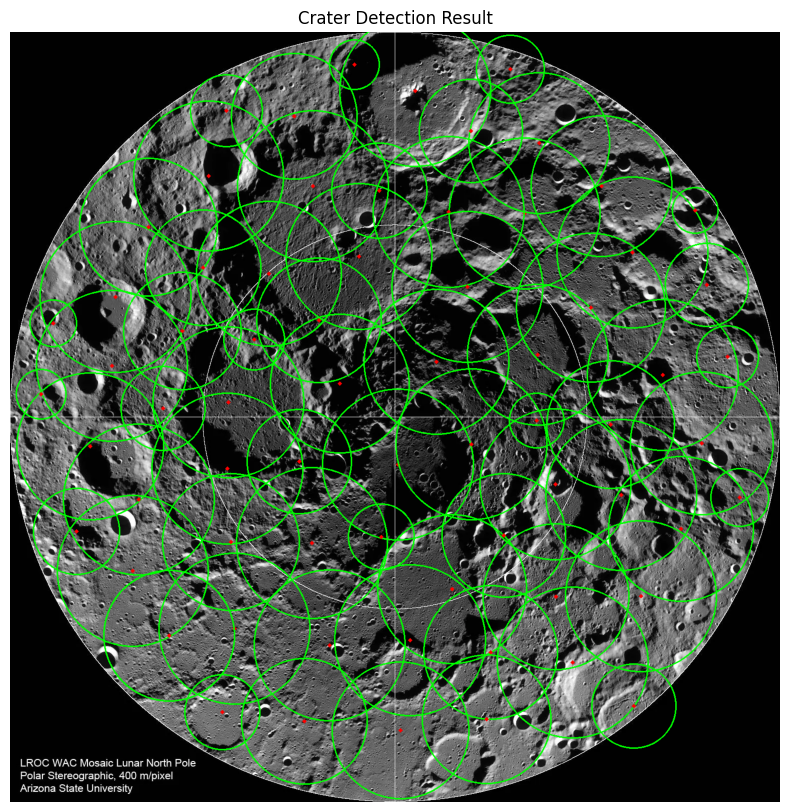

In [6]:
# Display result
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Crater Detection Result")
plt.axis("off")
plt.show()

## Conclusion
The analysis successfully demonstrates application of computer vision techniques on astronomical image data.

## Key Techniques Used
- OpenCV
- Hough Circle Transform
- Image Filtering
